In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

# Solution — Module 3: Regression

**Dataset:** NIST StRD Pontius (public domain) + UCI CCPP (CC BY 4.0, https://doi.org/10.24432/C5002N)

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
# ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)
plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Leelawadee UI", "Tahoma", "Thonburi"]

pont = pl.DataFrame(np.loadtxt(DATA / "Pontius.dat", skiprows=60, max_rows=40), schema={"y": pl.Float64, "x": pl.Float64}, orient="row")
ccpp = pl.read_csv(DATA / "ccpp_power_plant.csv")

## ข้อ A1 — quadratic fit เทียบ certified

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# กับดักตัวเลข: x ~ 10⁶ → x² ~ 10¹² เมทริกซ์ conditioning เลวมาก
# โมเดลเสถียร = np.polyfit (scale คอลัมน์ภายใน) หรือ scale x ก่อนแล้วแปลงกลับ
b2, b1, b0 = np.polyfit(pont["x"].to_numpy(), pont["y"].to_numpy(), 2)
print(f"คุณ  : B0={b0:.6g}, B1={b1:.6g}, B2={b2:.6g}")
print(f"NIST : B0=0.000673566, B1=0.000000732059, B2=-3.16082e-15")
pred = np.polyval([b2, b1, b0], pont["x"].to_numpy())
r2 = r2_score(pont["y"], pred)
rmse = float(np.sqrt(mean_squared_error(pont["y"], pred)))
print(f"R² = {r2:.6f}, RMSE = {rmse:.4g}")

คุณ  : B0=0.000673566, B1=7.32059e-07, B2=-3.16082e-15
NIST : B0=0.000673566, B1=0.000000732059, B2=-3.16082e-15
R² = 1.000000, RMSE = 0.0001973


สัมประสิทธิ์ตรงกับ NIST ถึงหลักของ rounding สังเกตด้วยว่าถ้าใช้ `LinearRegression` กับ `PolynomialFeatures` แบบดิบ ผลจะเพี้ยนไปต่างฟาก — ปัญหา conditioning ของตัวเลข ไม่ใช่ความผิดของโมเดล (NIST แก้แบบ centered จึงเสถียร) — ประเด็นเดียวกับเหตุผลที่เรา scale feature ก่อน regularization

## ข้อ A2 — residual สองโมเดล

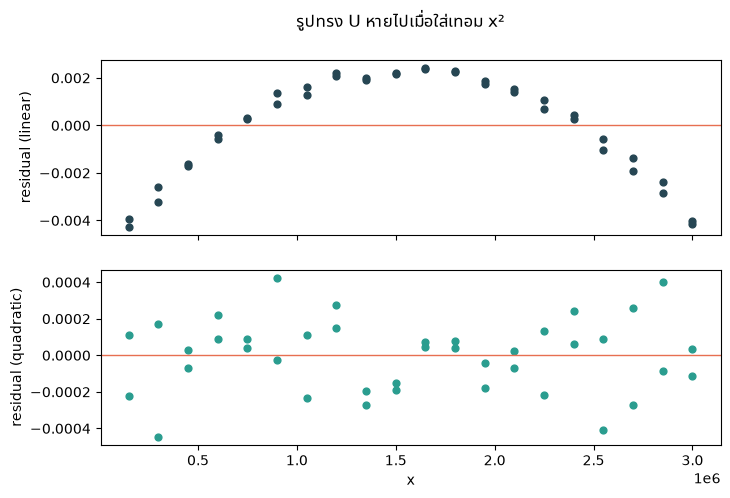

In [4]:
lin = LinearRegression().fit(pont.select("x"), pont["y"])
resid_lin = pont["y"].to_numpy() - lin.predict(pont.select("x"))
resid_q = pont["y"].to_numpy() - pred

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].scatter(pont["x"], resid_lin, s=24, color="#264653")
axes[0].axhline(0, color="#e76f51", lw=1)
axes[0].set_ylabel("residual (linear)")
axes[1].scatter(pont["x"], resid_q, s=24, color="#2a9d8f")
axes[1].axhline(0, color="#e76f51", lw=1)
axes[1].set_ylabel("residual (quadratic)")
axes[1].set_xlabel("x")
fig.suptitle("รูปทรง U หายไปเมื่อใส่เทอม x²")
plt.show()

**คำตอบ:** เทอม **B2·x²** คือสิ่งที่ดูดรูปทรง U ออกจาก residual — residual ของโมเดลที่ถูกต้องควรดูเหมือน noise ไม่มีโครง

## ข้อ A3 — extrapolation

RMSE in-range = 0.0001789 | RMSE extrapolated = 0.0003213


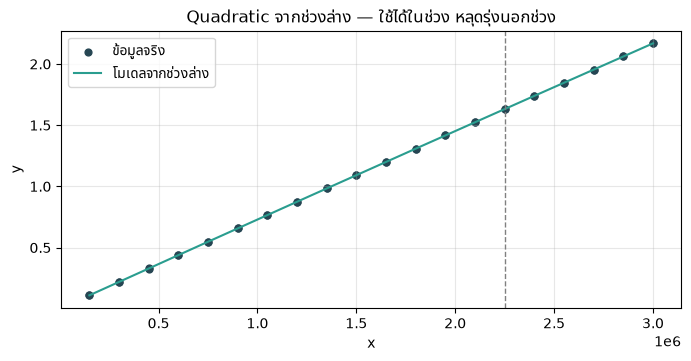

In [5]:
from sklearn.preprocessing import PolynomialFeatures

mask_in = pont["x"] <= 2_250_000
train_p, test_p = pont.filter(mask_in), pont.filter(~mask_in)

# scale x ด้วยสถิติของ train subset ก่อนพอดี (กัน conditioning แย่)
x_mean, x_std = train_p["x"].mean(), train_p["x"].std()
def poly2_scaled(frame):
    z = ((frame["x"].to_numpy() - x_mean) / x_std).reshape(-1, 1)
    return PolynomialFeatures(degree=2, include_bias=False).fit_transform(z)

poly_low = LinearRegression().fit(poly2_scaled(train_p), train_p["y"])
rmse_in = float(np.sqrt(mean_squared_error(train_p["y"], poly_low.predict(poly2_scaled(train_p)))))
rmse_out = float(np.sqrt(mean_squared_error(test_p["y"], poly_low.predict(poly2_scaled(test_p)))))
print(f"RMSE in-range = {rmse_in:.4g} | RMSE extrapolated = {rmse_out:.4g}")

grid = np.linspace(pont["x"].min(), pont["x"].max(), 200)
grid_df = pl.DataFrame({"x": grid})
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.scatter(pont["x"], pont["y"], s=24, color="#264653", label="ข้อมูลจริง")
ax.plot(grid, poly_low.predict(poly2_scaled(grid_df)), color="#2a9d8f", label="โมเดลจากช่วงล่าง")
ax.axvline(2_250_000, color="gray", ls="--", lw=1)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Quadratic จากช่วงล่าง — ใช้ได้ในช่วง หลุดรุ่งนอกช่วง")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

**สังเกต:** RMSE นอกช่วงโตกว่าในช่วงหลายเท่า และเส้นทางขวาเริ่มหลุดจากข้อมูล — extrapolation ไม่ใช่แค่ "แม่นน้อยลง" แต่อาจพาไปทิศทางใดก็ได้ที่โมเดลสั่ง เหตุผลที่ใบรับรอบสอบเทียบทุกใบระบุช่วงการใช้งาน

## ข้อ B1 — เทียบสามโมเดล

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

X = ccpp.select("AT", "V", "AP", "RH")
y = ccpp["PE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

candidates = [
    ("linear", make_pipeline(StandardScaler(), LinearRegression())),
    ("poly2+ridge(10)", make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), Ridge(alpha=10))),
    ("poly2+lasso(0.1)", make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), Lasso(alpha=0.1))),
]
r2s = {}
for name, model in candidates:
    model.fit(X_train, y_train)
    r2s[name] = model.score(X_test, y_test)
    print(f"{name:20s} test R² = {r2s[name]:.4f}")

lasso_model = candidates[2][1]
n_zero = int((np.abs(lasso_model.named_steps["lasso"].coef_) < 1e-10).sum())
print(f"สัมประสิทธิ์ที่ lasso กดเป็นศูนย์: {n_zero} จาก {len(lasso_model.named_steps['lasso'].coef_)}")

linear               test R² = 0.9301
poly2+ridge(10)      test R² = 0.9383
poly2+lasso(0.1)     test R² = 0.9380
สัมประสิทธิ์ที่ lasso กดเป็นศูนย์: 3 จาก 14


poly2 ดีกว่า linear เล็กน้อย (R² ~0.93 → ~0.94) — CCPP มีความโค้งจริงเล็ก ๆ และ lasso กด feature ที่ซ้ำซ้อน (เช่น AP², AP·RH) ทิ้งบางส่วน

## ข้อ B2 — เลือก alpha ด้วย GridSearchCV

In [7]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), Ridge())
search = GridSearchCV(pipe, {"ridge__alpha": [0.01, 0.1, 1, 10, 100]}, cv=5, scoring="r2")
search.fit(X_train, y_train)
best_alpha = search.best_params_["ridge__alpha"]
r2 = search.best_estimator_.score(X_test, y_test)
print(f"best alpha = {best_alpha}, CV R² = {search.best_score_:.4f}, test R² = {r2:.4f}")

best alpha = 1, CV R² = 0.9282, test R² = 0.9301


## ข้อ B3 — คำตอบ

คำถามที่ควรถามก่อนเชื่อ test R² = 0.9999:
1. **split แบบไหน** — แถว CCPP มาจากการวัดหลายปี; ถ้า split แบบสุ่ม แถวข้างเคียง (วันติดกัน) ตกอยู่คนละฝั่ง — test จึงใกล้เคียง train มากเกินจริง
2. **leakage** — เขา fit scaler/poly/alpha จากข้อมูลรวม test หรือไม่
3. **ตีความของ R² สูง** — CCPP เป็นการจำลองจาก physics-based model ที่ deterministic ค่อนข้างสูง R² สูงผิดปกติอาจแค่สะท้อนว่าข้อมูลง่าย ไม่ใช่โมเดลเก่ง
4. **นอกช่วง** — โมเดลพูดอะไรเกี่ยวกับ AT นอกช่วง 1.8–37 °C? (อะไรไม่ได้)
5. **ตัวเลขได้มาจากการลอง test หลายครั้งหรือไม่** — เปิด test ครั้งเดียวต่อโมเดลสุดท้าย